In [1]:
import pandas as pd
from datetime import datetime as dt
import matplotlib.pyplot as plt
import holidays

In [13]:
data = pd.read_excel("/Users/neil.sinclair@diconium.com/Projects/electricy-model/data/energy_profile.xlsx", header=2)
data.drop(columns=["Unnamed: 0"], inplace=True)

months = ["January", "February", "March", "April", "May", "June", "July", "August", "September", "October", "November", "December"]
data_types = ["SA", "FT", "WT"]
new_months = []
for month in months:
  for data_type in data_types:
    new_months.append(month+"_"+data_type)

data.columns = ["Time"] + new_months
data.drop(index=0, inplace=True)
data.dropna(axis=0,subset=["Time"], inplace=True)

data = data.melt(id_vars="Time")

data.columns = ["Time Period", "Date", "value"]
data["month_name"] = data.Date.apply(lambda x: x.split("_")[0])
data["day_type"] = data.Date.apply(lambda x: x.split("_")[1])
data["time"] = data["Time Period"].apply(lambda x: x.split("-")[0])
data["time"] = pd.to_datetime(data["time"], format="%H:%M").dt.time

data.drop(columns=["Date", "Time Period"], inplace=True)


In [63]:
day_map = {
  "Monday": "WT",
  "Tuesday": "WT",
  "Wednesday": "WT",
  "Thursday": "WT",
  "Friday": "WT",
  "Saturday": "SA",
  "Sunday": "FT"
}

de_holidays = holidays.Germany(years=2025)

# 1. Create all 15-minute timestamps for 2025
dt_index = pd.date_range(
    start="2025-01-01 00:00",
    end="2025-12-31 23:45",   # last 15-minute slot of the year
    freq="15min"
)

df = pd.DataFrame({"datetime": dt_index})

# 2. Add date, time, weekday name
df["date"] = df["datetime"].dt.date
df["time"] = df["datetime"].dt.time
df["weekday"] = df["datetime"].dt.day_name() 
df["month_name"] = df["datetime"].dt.month_name()
# df["weekday"] = df["datetime"].dt.day_name(locale="de_DE")  # if you have locale set up
# Name of holiday (or None)
df["holiday_name"] = df["datetime"].dt.date.map(de_holidays.get)

# Boolean flag for “is public holiday?”
df["is_holiday"] = df["holiday_name"].notna()
df["day_type"] = df["weekday"].map(day_map)
df.loc[df["is_holiday"], "day_type"] = "FT"

pd.set_option("display.max_rows", 10)

df = df.merge(
  data,
  on = ["month_name", "day_type", "time"],
  how="left"
).drop(columns=["day_type", "time", "date", "holiday_name", "is_holiday"])

df = df.set_index("datetime")

df_hourly = pd.DataFrame(df.resample("h")["value"].mean()).reset_index()

df_hourly

,datetime,value
0,2025-01-01 00:00:00,14.4835
1,2025-01-01 01:00:00,14.15175
2,2025-01-01 02:00:00,13.97275
3,2025-01-01 03:00:00,13.861
4,2025-01-01 04:00:00,13.95375
...,...,...
8755,2025-12-31 19:00:00,27.46925
8756,2025-12-31 20:00:00,23.03
8757,2025-12-31 21:00:00,20.19275
8758,2025-12-31 22:00:00,17.676


In [45]:
pd.set_option("display.max_rows", 100)
# df[df.value.isna()].tail(40)

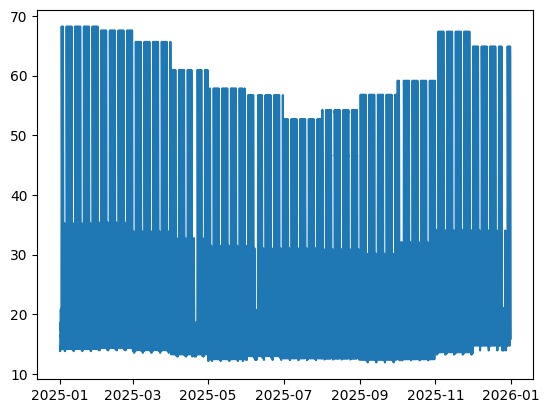

In [49]:
plt.plot(df["datetime"], df["value"])

In [43]:
df[df.weekday=="Saturday"]["value"].sum()

0

In [66]:
day_ahead = pd.read_csv("data/day_ahead_2025.csv", sep=";")
day_ahead.head(2)

,Start date,End date,Germany/Luxembourg [€/MWh] Original resolutions,∅ DE/LU neighbours [€/MWh] Original resolutions,Belgium [€/MWh] Original resolutions,Denmark 1 [€/MWh] Original resolutions,Denmark 2 [€/MWh] Original resolutions,France [€/MWh] Original resolutions,Netherlands [€/MWh] Original resolutions,Norway 2 [€/MWh] Original resolutions,Austria [€/MWh] Original resolutions,Poland [€/MWh] Original resolutions,Sweden 4 [€/MWh] Original resolutions,Switzerland [€/MWh] Original resolutions,Czech Republic [€/MWh] Original resolutions,DE/AT/LU [€/MWh] Original resolutions,Northern Italy [€/MWh] Original resolutions,Slovenia [€/MWh] Original resolutions,Hungary [€/MWh] Original resolutions
0,"Jan 1, 2025 12:00 AM","Jan 1, 2025 12:15 AM",2.16,27.99,10.62,2.16,2.54,12.36,13.62,16.35,109.0,15.41,2.67,102.2,21.0,-,138.70,118.46,147.25
1,"Jan 1, 2025 12:15 AM","Jan 1, 2025 12:30 AM",2.16,27.99,10.62,2.16,2.54,12.36,13.62,16.35,109.0,15.41,2.67,102.2,21.0,-,138.70,118.46,147.25


In [67]:
day_ahead = day_ahead[["Start date", "End date", "Germany/Luxembourg [€/MWh] Original resolutions", "∅ DE/LU neighbours [€/MWh] Original resolutions"]]

day_ahead.columns = ["start_date", "end_date", "de_price", "neighbour_price"]
day_ahead["start_date"] = pd.to_datetime(day_ahead["start_date"], format="%b %d, %Y %I:%M %p")
day_ahead["end_date"] = pd.to_datetime(day_ahead["end_date"], format="%b %d, %Y %I:%M %p")
day_ahead.head()

,start_date,end_date,de_price,neighbour_price
0,2025-01-01 00:00:00,2025-01-01 00:15:00,2.16,27.99
1,2025-01-01 00:15:00,2025-01-01 00:30:00,2.16,27.99
2,2025-01-01 00:30:00,2025-01-01 00:45:00,2.16,27.99
3,2025-01-01 00:45:00,2025-01-01 01:00:00,2.16,27.99
4,2025-01-01 01:00:00,2025-01-01 01:15:00,1.60,29.36


In [19]:
df_combined = df.merge(
    day_ahead[["start_date", "de_price", "neighbour_price"]],
    left_on="datetime",
    right_on="start_date",
    how="left"
).drop(columns=["start_date"])

df_combined.head()

,datetime,date,time,weekday,month_name,holiday_name,is_holiday,day_type,value,de_price,neighbour_price
0,2025-01-01 00:00:00,2025-01-01,00:00:00,Wednesday,January,Neujahr,True,FT,14.658,2.16,27.99
1,2025-01-01 00:15:00,2025-01-01,00:15:00,Wednesday,January,Neujahr,True,FT,14.602,2.16,27.99
2,2025-01-01 00:30:00,2025-01-01,00:30:00,Wednesday,January,Neujahr,True,FT,14.43,2.16,27.99
3,2025-01-01 00:45:00,2025-01-01,00:45:00,Wednesday,January,Neujahr,True,FT,14.244,2.16,27.99
4,2025-01-01 01:00:00,2025-01-01,01:00:00,Wednesday,January,Neujahr,True,FT,14.226,1.60,29.36


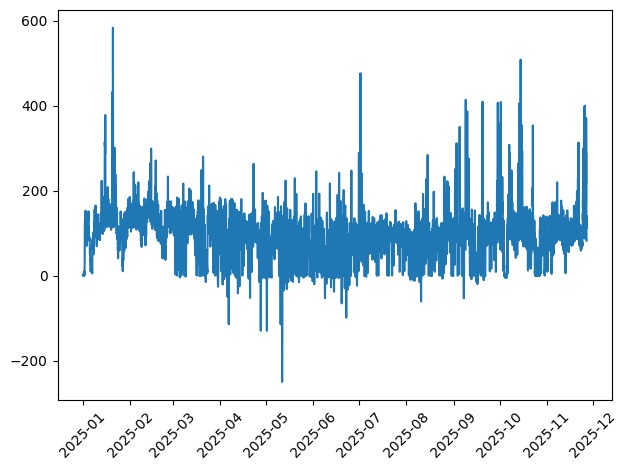

In [23]:
plt.plot(df_combined["datetime"], df_combined["de_price"])
plt.xticks(rotation=45)
plt.tight_layout()

Text(0.5, 1.0, 'Distribution of Day-Ahead Prices (Germany/Luxembourg)')

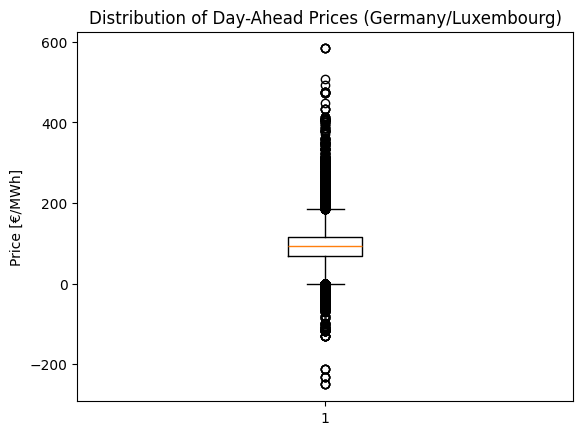

In [28]:
plt.boxplot(df_combined["de_price"].dropna())
plt.ylabel("Price [€/MWh]")
plt.title("Distribution of Day-Ahead Prices (Germany/Luxembourg)")

In [68]:
day_ahead_hourly = pd.DataFrame(df_combined.resample("h", on="datetime")["de_price"].mean()).reset_index()
day_ahead_hourly

,datetime,de_price
0,2025-01-01 00:00:00,2.16
1,2025-01-01 01:00:00,1.60
2,2025-01-01 02:00:00,0.00
3,2025-01-01 03:00:00,-0.01
4,2025-01-01 04:00:00,-0.01
...,...,...
8755,2025-12-31 19:00:00,NaN
8756,2025-12-31 20:00:00,NaN
8757,2025-12-31 21:00:00,NaN
8758,2025-12-31 22:00:00,NaN


In [87]:
ANNUAL_USAGE = 2_00_000
SCALE_FACTOR = ANNUAL_USAGE /1_000_000
FLAT_RATE_C_PER_KWH = 30

# additional costs
NET_USAGE = 8.71
TAX_RATE = 0.19
ELECTRICITY_TAX = 2.05
ADDITIONAL_COST = 1.88
KONZESSION = 1.66
GRID_FEES = 9.85
CHP_SURCHARGE = 0.45
COMBINED_ADDITIONAL_COSTS = NET_USAGE + ELECTRICITY_TAX + ADDITIONAL_COST + KONZESSION + GRID_FEES + CHP_SURCHARGE 

df_usage_and_price = df_hourly.merge(
    day_ahead_hourly,
    on="datetime",
    how="left"
).rename(columns={"de_price": "c_per_kwh_variable", "value": "raw_kwh_usage"})

df_usage_and_price["c_per_kwh_variable"] = df_usage_and_price["c_per_kwh_variable"] / 10 # Convert €/MWh to c€/kWh

# Fill missing prices with average price
df_usage_and_price.loc[df_usage_and_price.c_per_kwh_variable.isna(), "c_per_kwh_variable"] = df_usage_and_price["c_per_kwh_variable"].mean()
df_usage_and_price["scaled_kwh_usage"] = df_usage_and_price["raw_kwh_usage"] * SCALE_FACTOR
df_usage_and_price["c_fixed_costs_kwh"] = COMBINED_ADDITIONAL_COSTS

df_usage_and_price["c_total_variable_cost"] = (
    (df_usage_and_price["scaled_kwh_usage"] * (df_usage_and_price["c_per_kwh_variable"] + df_usage_and_price["c_fixed_costs_kwh"])) * (1 + TAX_RATE)
)


# df_usage_and_price["c_additional_variable_cost"] = df_usage_and_price["scaled_kwh_usage"] * df_usage_and_price["c_additional_costs_kwh"]
# df_usage_and_price["c_final_cost"]  = (df_usage_and_price["c_raw_variable_cost"] + df_usage_and_price["c_additional_variable_cost"]) * (1 + TAX_RATE)
# df_usage_and_price["flat_rate_cost"] = FLAT_RATE_C_PER_KWH

df_usage_and_price

,datetime,raw_kwh_usage,c_per_kwh_variable,scaled_kwh_usage,c_fixed_costs_kwh,c_total_variable_cost
0,2025-01-01 00:00:00,14.4835,0.216000,2.8967,24.6,85.542564
1,2025-01-01 01:00:00,14.15175,0.160000,2.83035,24.6,83.394565
2,2025-01-01 02:00:00,13.97275,0.000000,2.79455,24.6,81.807657
3,2025-01-01 03:00:00,13.861,-0.001000,2.7722,24.6,81.150084
4,2025-01-01 04:00:00,13.95375,-0.001000,2.79075,24.6,81.693095
...,...,...,...,...,...,...
8755,2025-12-31 19:00:00,27.46925,8.896335,5.49385,24.6,218.988371
8756,2025-12-31 20:00:00,23.03,8.896335,4.606,24.6,183.598103
8757,2025-12-31 21:00:00,20.19275,8.896335,4.03855,24.6,160.979183
8758,2025-12-31 22:00:00,17.676,8.896335,3.5352,24.6,140.91533


In [ ]:

df_usage_and_price

,datetime,raw_kwh_usage,c_per_kwh,scaled_kwh_usage,c_raw_cost
0,2025-01-01 00:00:00,14.4835,0.216000,2.8967,3.128436
1,2025-01-01 01:00:00,14.15175,0.160000,2.83035,2.26428
2,2025-01-01 02:00:00,13.97275,0.000000,2.79455,0.0
3,2025-01-01 03:00:00,13.861,-0.001000,2.7722,-0.013861
4,2025-01-01 04:00:00,13.95375,-0.001000,2.79075,-0.013954
...,...,...,...,...,...
8755,2025-12-31 19:00:00,27.46925,8.896335,5.49385,244.375655
8756,2025-12-31 20:00:00,23.03,8.896335,4.606,204.882599
8757,2025-12-31 21:00:00,20.19275,8.896335,4.03855,179.641472
8758,2025-12-31 22:00:00,17.676,8.896335,3.5352,157.251621


In [82]:
df_usage_and_price.c_raw_cost.sum() / 100

22403.301742472373